In [ ]:
import zipfile
import os
from google.colab import drive

# Authenticate and mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

# Specify the zip file paths
zip_path_clear = '/content/drive/MyDrive/Clear_Images-20240808T071449Z-001.zip'  # Replace with your own first zip file path in Google Colab
zip_path_hazy = '/content/drive/MyDrive/Hazy_Images-20240808T071517Z-001.zip'  # Replace with your own second zip file path in Google Colab

In [ ]:
# Specify the destination folder names for extracted images
extract_path_clear = '/content/drive/My Drive/Clear_Images'
extract_path_hazy = '/content/drive/My Drive/Hazy_Images'

In [ ]:
# Create extraction folders if they don't exist
import os
os.makedirs(extract_path_clear, exist_ok=True)
os.makedirs(extract_path_hazy, exist_ok=True)

In [ ]:
# Extract clear_imgs.zip
with zipfile.ZipFile(zip_path_clear, 'r') as zip_ref:
    zip_ref.extractall(extract_path_clear)

In [ ]:
try:
    with zipfile.ZipFile(zip_path_hazy, 'r') as zip_ref_hazy:
        zip_ref_hazy.extractall(extract_path_hazy)
    print("Hazy images extracted successfully.")
except Exception as e:
    print(f"Error extracting hazy images: {e}")

Hazy images extracted successfully.


In [ ]:
import os

clear_images_path = '/content/drive/MyDrive/Clear_Images'
hazy_images_path = '/content/drive/MyDrive/Hazy_Images'

def sort_images_in_folder(folder_path):
    images = [f for f in os.listdir(folder_path) if f.endswith('.tif')]
    images.sort(key=lambda x: int(os.path.splitext(x)[0]))
    for idx, image in enumerate(images, start=1):
        old_image_path = os.path.join(folder_path, image)
        new_image_path = os.path.join(folder_path, f"{idx:04d}.tif")  # Adjust the format as needed
        if old_image_path != new_image_path:
            os.rename(old_image_path, new_image_path)

sort_images_in_folder(clear_images_path)
sort_images_in_folder(hazy_images_path)

In [ ]:
import os

clear_images_path = '/content/drive/MyDrive/Clear_Images/Clear_Images/Clear_imgs'
hazy_images_path = '/content/drive/MyDrive/Hazy_Images/Hazy_Images/Hazy_img'

def count_images_in_folder(folder_path):
    images = [f for f in os.listdir(folder_path) if f.endswith('.tif')]
    return len(images)

clear_images_count = count_images_in_folder(clear_images_path)
hazy_images_count = count_images_in_folder(hazy_images_path)

print(f"Number of images in Clear_Images folder: {clear_images_count}")
print(f"Number of images in Hazy_Images folder: {hazy_images_count}")

Number of images in Clear_Images folder: 224
Number of images in Hazy_Images folder: 224


In [ ]:
!pip install --upgrade scikit-image  # Upgrade scikit-image to the latest version
!pip install imagecodecs  # Install the imagecodecs module

import os
from PIL import Image
from skimage import img_as_ubyte
from skimage.filters import gaussian
from imagecodecs import imread # Now this import should work


# Function for preprocessing images
def preprocess_images(input_folder, output_folder):
    for root, dirs, files in os.walk(input_folder):
        for file in files:
            if file.endswith('.tif'):
                input_image_path = os.path.join(root, file)
                relative_folder_path = os.path.relpath(root, input_folder)
                output_subfolder = os.path.join(output_folder, relative_folder_path)
                os.makedirs(output_subfolder, exist_ok=True)

                img = imread(input_image_path)
                # Apply preprocessing techniques here, e.g., noise removal
                if img.ndim == 3:  # Check if the image is multichannel
                    img_processed = gaussian(img, sigma=1, channel_axis=-1)  # Apply Gaussian filter along the channel axis
                else:
                    img_processed = gaussian(img, sigma=1)  # Apply Gaussian filter to a single-channel image
                img_processed = img_as_ubyte(img_processed)  # Convert image to 8-bit
                # Save preprocessed image
                output_image_path = os.path.join(output_subfolder, file)
                Image.fromarray(img_processed).save(output_image_path)

# Path to the input and output folders
clear_images_input_folder = '/content/drive/MyDrive/Clear_Images/Clear_Images'
hazy_images_input_folder = '/content/drive/MyDrive/Hazy_Images/Hazy_Images'
clear_images_output_folder = '/content/drive/My Drive/Preprocessed_Clear_Images'
hazy_images_output_folder = '/content/drive/My Drive/Preprocessed_Hazy_Images'

# Preprocess clear images
preprocess_images(clear_images_input_folder, clear_images_output_folder)

# Preprocess hazy images
preprocess_images(hazy_images_input_folder, hazy_images_output_folder)

In [ ]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, UpSampling2D, Add, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
import tensorflow as tf

from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, Dense, Multiply, Conv2D, Concatenate
from tensorflow.keras import backend as K # Import Keras backend

# Channel Attention Module (CAM)
def channel_attention(x, filters, reduction_ratio=8):
    avg_pool = GlobalAveragePooling2D()(x)
    max_pool = GlobalMaxPooling2D()(x)

    avg_pool = Dense(filters // reduction_ratio, activation='relu')(avg_pool)
    avg_pool = Dense(filters, activation='sigmoid')(avg_pool)

    max_pool = Dense(filters // reduction_ratio, activation='relu')(max_pool)
    max_pool = Dense(filters, activation='sigmoid')(max_pool)

    attention = Add()([avg_pool, max_pool])
    attention = Multiply()([x, attention])

    return attention

# Spatial Attention Module (SAM) - Modified to use Lambda layer
def spatial_attention(x):
    # Wrap TensorFlow operations in a Lambda layer
    avg_pool = Lambda(lambda x: K.mean(x, axis=-1, keepdims=True))(x)
    max_pool = Lambda(lambda x: K.max(x, axis=-1, keepdims=True))(x)

    concat = Concatenate(axis=-1)([avg_pool, max_pool])
    attention = Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(concat)
    attention = Multiply()([x, attention])

    return attention

# CBAM Block: Combine Channel and Spatial Attention
def cbam_block(x, filters):
    x = channel_attention(x, filters)
    x = spatial_attention(x)
    return x


# U-Net with Residual and Attention
def unet_residual_attention_model(input_shape):
    inputs = Input(shape=input_shape)

    # Encoder with residual and attention blocks
    def conv_block(x, filters, kernel_size=3):
        x = Conv2D(filters, kernel_size, padding='same')(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = Conv2D(filters, kernel_size, padding='same')(x)
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        return x

    def residual_attention_block(x, filters):
        res = Conv2D(filters, 1, padding='same')(x)
        x = conv_block(x, filters)
        x = cbam_block(x, filters)  # Apply CBAM (attention) after the residual block
        return Add()([x, res])

    # Encoder path
    conv1 = residual_attention_block(inputs, 64)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = residual_attention_block(pool1, 128)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = residual_attention_block(pool2, 256)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    conv4 = residual_attention_block(pool3, 512)

    # Decoder path with skip connections
    up5 = UpSampling2D(size=(2, 2))(conv4)
    concat5 = Concatenate()([up5, conv3])
    conv5 = residual_attention_block(concat5, 256)

    up6 = UpSampling2D(size=(2, 2))(conv5)
    concat6 = Concatenate()([up6, conv2])
    conv6 = residual_attention_block(concat6, 128)

    up7 = UpSampling2D(size=(2, 2))(conv6)
    concat7 = Concatenate()([up7, conv1])
    conv7 = residual_attention_block(concat7, 64)

    # Output layer (using sigmoid to map to image)
    outputs = Conv2D(3, 1, padding='same', activation='sigmoid')(conv7)

    # Add residual connection from input
    outputs = Add()([inputs, outputs])

    model = Model(inputs=inputs, outputs=outputs)

    return model

# Define combined loss (MSE + Perceptual Loss)
def combined_loss(y_true, y_pred):
    vgg = VGG16(include_top=False, weights='imagenet', input_shape=(256, 256, 3))
    vgg.trainable = False
    feature_extractor = Model(inputs=vgg.input, outputs=vgg.get_layer('block5_conv2').output)

    # Perceptual Loss based on feature maps from VGG16
    y_true_features = feature_extractor(y_true)
    y_pred_features = feature_extractor(y_pred)
    perceptual_loss = tf.reduce_mean(tf.square(y_true_features - y_pred_features))

    # Mean Squared Error Loss
    mse_loss = tf.reduce_mean(tf.square(y_true - y_pred))

    # Combined Loss
    return 0.5 * mse_loss + 0.5 * perceptual_loss

# Compile the improved model
input_shape = (256, 256, 3)  # Example input shape
model = unet_residual_attention_model(input_shape)
model.compile(optimizer=Adam(learning_rate=1e-4), loss=combined_loss)

# Print model summary
model.summary()


# Print the model summary
model.summary()


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15            │ (None, 256, 256, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_384 (Conv2D)       │ (None, 256, 256, 64)   │          1,792 │ input_layer_15[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_186   │ (None, 256, 256, 64)   │            256 │ conv2d_384[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_186            │ (None, 256, 256, 64)   │              0 │ batch_normalization_1… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_385 (Conv2D)       │ (None, 256, 256, 64)   │         36,928 │ activation_186[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_187   │ (None, 256, 256, 64)   │            256 │ conv2d_385[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_187            │ (None, 256, 256, 64)   │              0 │ batch_normalization_1… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d… │ (None, 64)             │              0 │ activation_187[0][0]   │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_max_pooling2d_93   │ (None, 64)             │              0 │ activation_187[0][0]   │
│ (GlobalMaxPooling2D)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_372 (Dense)         │ (None, 8)              │            520 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_374 (Dense)         │ (None, 8)              │            520 │ global_max_pooling2d_… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_373 (Dense)         │ (None, 64)             │            576 │ dense_372[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_375 (Dense)         │ (None, 64)             │            576 │ dense_374[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_197 (Add)             │ (None, 64)             │              0 │ dense_373[0][0],       │
│                           │                        │                │ dense_375[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply_184 (Multiply)   │ (None, 256, 256, 64)   │              0 │ activation_187[0][0],  │
│                           │                        │                │ add_197[0][0]          │
├──────────────────────

 Total params: 8,446,936 (32.22 MB)

 Trainable params: 8,441,304 (32.20 MB)

 Non-trainable params: 5,632 (22.00 KB)

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15            │ (None, 256, 256, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_384 (Conv2D)       │ (None, 256, 256, 64)   │          1,792 │ input_layer_15[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_186   │ (None, 256, 256, 64)   │            256 │ conv2d_384[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_186            │ (None, 256, 256, 64)   │              0 │ batch_normalization_1… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_385 (Conv2D)       │ (None, 256, 256, 64)   │         36,928 │ activation_186[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_187   │ (None, 256, 256, 64)   │            256 │ conv2d_385[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_187            │ (None, 256, 256, 64)   │              0 │ batch_normalization_1… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d… │ (None, 64)             │              0 │ activation_187[0][0]   │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_max_pooling2d_93   │ (None, 64)             │              0 │ activation_187[0][0]   │
│ (GlobalMaxPooling2D)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_372 (Dense)         │ (None, 8)              │            520 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_374 (Dense)         │ (None, 8)              │            520 │ global_max_pooling2d_… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_373 (Dense)         │ (None, 64)             │            576 │ dense_372[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_375 (Dense)         │ (None, 64)             │            576 │ dense_374[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_197 (Add)             │ (None, 64)             │              0 │ dense_373[0][0],       │
│                           │                        │                │ dense_375[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply_184 (Multiply)   │ (None, 256, 256, 64)   │              0 │ activation_187[0][0],  │
│                           │                        │                │ add_197[0][0]          │
├──────────────────────

 Total params: 8,446,936 (32.22 MB)

 Trainable params: 8,441,304 (32.20 MB)

 Non-trainable params: 5,632 (22.00 KB)

In [ ]:
#5
import os
import numpy as np
from PIL import Image

def data_generator(hazy_dir, clear_dir, batch_size):
    while True:
        hazy_images = []
        clear_images = []
        for i in range(66, 290):
            filename = str(i) + '.tif'
            img = Image.open(os.path.join(hazy_dir, filename))
            hazy_images.append(np.array(img))
            clear_filename = str(i) + '.tif'
            clear_img = Image.open(os.path.join(clear_dir, clear_filename))
            clear_images.append(np.array(clear_img))
            if len(hazy_images) == batch_size:
                X = np.array(hazy_images) / 255.0
                y = np.array(clear_images) / 255.0
                yield X, y
                hazy_images = []
                clear_images = []

In [ ]:
#6
# Set the directories and batch size
hazy_dir = '/content/drive/MyDrive/Preprocessed_Hazy_Images/Hazy_img'
clear_dir = '/content/drive/MyDrive/Preprocessed_Clear_Images/Clear_imgs'
batch_size = 8

# Get the list of file names in the directories
hazy_filenames = os.listdir(hazy_dir)
clear_filenames = [os.path.splitext(filename)[0] + '_clear.tif' for filename in hazy_filenames]

# Split the file names into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    hazy_filenames, clear_filenames, test_size=0.2, random_state=42)

In [ ]:
#7
import os

folder_path1 = "/content/drive/MyDrive/Preprocessed_Hazy_Images/Hazy_img" # Replace with the path to your folder
num_images1 = len(os.listdir(folder_path1))
print("Number of images in folder:", num_images1)

folder_path2 = "/content/drive/MyDrive/Preprocessed_Clear_Images/Clear_imgs" # Replace with the path to your folder
num_images2 = len(os.listdir(folder_path2))
print("Number of images in folder:", num_images2)

Number of images in folder: 224
Number of images in folder: 224


In [ ]:
#8
from sklearn.model_selection import train_test_split

#Split the file names into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    hazy_filenames, clear_filenames, test_size=0.2, random_state=42)

In [ ]:
#9
# Define data generators
train_generator = data_generator(hazy_dir, clear_dir, batch_size=batch_size)
test_generator = data_generator(hazy_dir, clear_dir, batch_size=batch_size)

In [ ]:
#10
# Build the model
model = unet_residual_attention_model(input_shape=(None, None, 3))

In [ ]:
#11
# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

In [ ]:
#12
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print("GPU available:", True)
    print("CUDA version:", gpu_devices[0].name)
else:
    print("GPU available:", False)

TensorFlow version: 2.17.0
GPU available: True
CUDA version: /physical_device:GPU:0


In [ ]:
#13

import matplotlib.pyplot as plt

# Train the model and collect the loss and accuracy data
history = model.fit(train_generator, epochs=100, steps_per_epoch=len(X_train) // batch_size,
          validation_data=test_generator, validation_steps=len(X_test) // batch_size)

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 95s 3s/step - loss: 0.1005 - val_loss: 0.0338
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - loss: 0.0321 - val_loss: 0.0314
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - loss: 0.0371 - val_loss: 0.0340
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - loss: 0.0344 - val_loss: 0.0406
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - loss: 0.0330 - val_loss: 0.0308
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - loss: 0.0342 - val_loss: 0.0346
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - loss: 0.0323 - val_loss: 0.0321
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - loss: 0.0362 - val_loss: 0.0310
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - loss: 0.0341 - val_loss: 0.0371
Epoch 10/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - loss: 0.0333 - val_loss: 0.0380
Epoch 11/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - loss: 0.0335 - val_loss: 0.0335
Epoch 12/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - loss: 0.0

In [ ]:
#14
# Save the model
#14
# Save the model
model.save('/content/drive/MyDrive/dehaze_model.keras') # Change the file extension to .keras or .h5

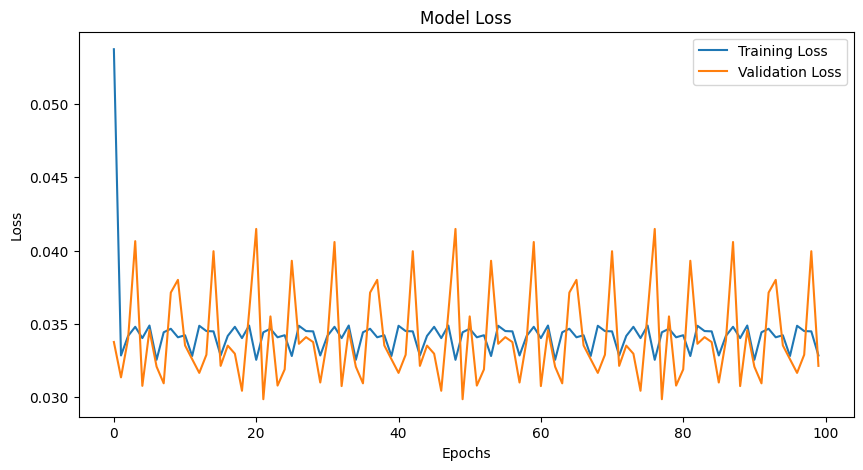

In [ ]:
# Create subplots to visualize the loss and accuracy data
fig, (ax1) = plt.subplots(1, figsize=(10, 5))

# Plot the training and validation loss data
ax1.plot(history.history['loss'], label='Training Loss')
ax1.plot(history.history['val_loss'], label='Validation Loss')
ax1.set_title('Model Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()


In [ ]:
#15
train_loss = model.evaluate(train_generator, steps=len(X_train) // batch_size)
print('Train loss:', train_loss)

22/22 ━━━━━━━━━━━━━━━━━━━━ 15s 685ms/step - loss: 0.0364
Train loss: 0.03335738554596901


In [ ]:
#16
# Evaluate the model on the test set
mse = model.evaluate(test_generator, steps=len(X_test)//batch_size)
print("Mean Squared Error on Test Set:", mse)

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 686ms/step - loss: 0.0350
Mean Squared Error on Test Set: 0.03457704931497574


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


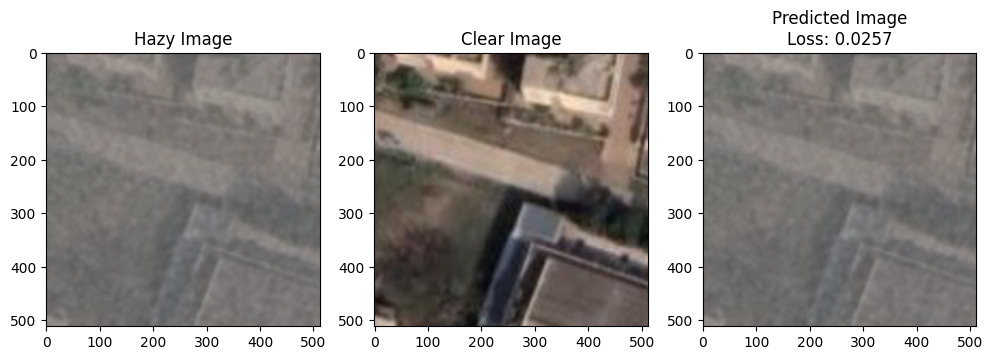

In [ ]:
#17
import os
from matplotlib import pyplot as plt
from PIL import Image
# Select an image index to evaluate
idx = 0
hazy_dir = '/content/drive/MyDrive/Preprocessed_Hazy_Images/Hazy_img'
clear_dir = '/content/drive/MyDrive/Preprocessed_Clear_Images/Clear_imgs'
batch_size = 8
# Load the hazy and clear images

hazy_image = Image.open(os.path.join(hazy_dir, '/content/drive/MyDrive/Preprocessed_Hazy_Images/Hazy_img/287.tif'))
clear_image = Image.open(os.path.join(clear_dir, '/content/drive/MyDrive/Preprocessed_Clear_Images/Clear_imgs/287.tif'))
# Generate a prediction for the hazy image
hazy_array = np.array(hazy_image) / 255.0
hazy_array = np.expand_dims(hazy_array, axis=0)

#model = load_model('/content/drive/MyDrive/dehaze_model.h1')
predicted_array = model.predict(hazy_array)[0]
predicted_image = Image.fromarray(np.uint8(predicted_array*255))


clear_array = np.array(clear_image) / 255.0

loss = np.mean(np.square(clear_array - predicted_array))

fig, ax = plt.subplots(ncols=3, figsize=(12, 4))
ax[0].imshow(hazy_image)
ax[0].set_title('Hazy Image')
ax[1].imshow(clear_image)
ax[1].set_title('Clear Image')
ax[2].imshow(predicted_image)
ax[2].set_title(f'Predicted Image\nLoss: {loss:.4f}')
plt.show()

In [ ]:
model1 = unet_residual_attention_model(input_shape=(None, None, 3))
model1.load_weights('/content/drive/MyDrive/dehaze_model.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


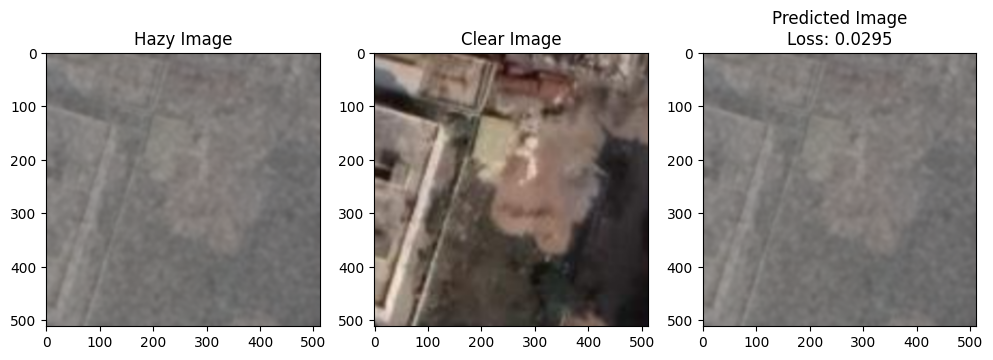

In [ ]:
#17
import os
from matplotlib import pyplot as plt
from PIL import Image
# Select an image index to evaluate
idx = 0
hazy_dir = '/content/drive/MyDrive/Preprocessed_Hazy_Images/Hazy_img'
clear_dir = '/content/drive/MyDrive/Preprocessed_Clear_Images/Clear_imgs'
batch_size = 8
# Load the hazy and clear images

hazy_image = Image.open(os.path.join(hazy_dir, '/content/drive/MyDrive/Preprocessed_Hazy_Images/Hazy_img/288.tif'))
clear_image = Image.open(os.path.join(clear_dir, '/content/drive/MyDrive/Preprocessed_Clear_Images/Clear_imgs/288.tif'))
# Generate a prediction for the hazy image
hazy_array = np.array(hazy_image) / 255.0
hazy_array = np.expand_dims(hazy_array, axis=0)

#model = load_model('/content/drive/MyDrive/dehaze_model.h1')
predicted_array = model1.predict(hazy_array)[0]
predicted_image = Image.fromarray(np.uint8(predicted_array*255))


clear_array = np.array(clear_image) / 255.0

loss = np.mean(np.square(clear_array - predicted_array))

fig, ax = plt.subplots(ncols=3, figsize=(12, 4))
ax[0].imshow(hazy_image)
ax[0].set_title('Hazy Image')
ax[1].imshow(clear_image)
ax[1].set_title('Clear Image')
ax[2].imshow(predicted_image)
ax[2].set_title(f'Predicted Image\nLoss: {loss:.4f}')
plt.show()

In [ ]:
#14
# Save the model
model.save('/content/drive/MyDrive/dehaze_model.keras')

In [ ]:
model1_45 =unet_residual_attention_model(input_shape=(None, None, 3))
model1_45.load_weights('/content/drive/MyDrive/dehaze_model.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


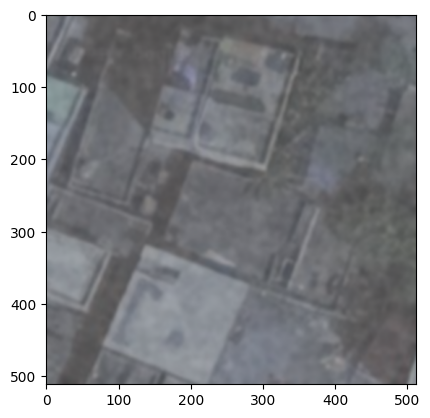

In [ ]:
#18
import cv2
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model


# Load hazy image
hazy_img = cv2.imread('/content/drive/MyDrive/Preprocessed_Hazy_Images/Hazy_img/166.tif')

# Preprocess the hazy image
hazy_img = hazy_img / 255.0
hazy_img = np.expand_dims(hazy_img, axis=0)

# Apply the dehazing model to the hazy image
dehazed_img = model1.predict(hazy_img)[0]

# Display the dehazed image using matplotlib
plt.imshow(dehazed_img)
plt.show()


In [ ]:
import os
import numpy as np
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# Load the hazy and clear images
hazy_image = Image.open(os.path.join(hazy_dir, '167.tif'))
clear_image = Image.open(os.path.join(clear_dir, '167.tif'))

# Resize the hazy image to the same dimensions as the clear image
hazy_image_resized = hazy_image.resize(clear_image.size)

# Convert images to numpy arrays
hazy_array_resized = np.array(hazy_image_resized) / 255.0
clear_array = np.array(clear_image) / 255.0

# Ensure that both arrays have the same dtype
hazy_array_resized = hazy_array_resized.astype(np.float32)
clear_array = clear_array.astype(np.float32)

# Generate a prediction for the resized hazy image
predicted_array = model.predict(np.expand_dims(hazy_array_resized, axis=0))[0]

# Calculate PSNR and SSIM
psnr_value = psnr(clear_array, predicted_array, data_range=1.0)
ssim_value = ssim(clear_array, predicted_array, data_range=1.0, channel_axis=-1)

print("Peak Signal-to-Noise Ratio (PSNR):", psnr_value)
print("Structural Similarity Index (SSIM):", ssim_value)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Peak Signal-to-Noise Ratio (PSNR): 14.922074088612828
Structural Similarity Index (SSIM): 0.6520631
